# Tesla Stock Price Prediction using SimpleRNN and LSTM

This notebook contains the complete pipeline for predicting the stock price of Tesla (TSLA) using Deep Learning. We explore Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks, comparing their performance on predicting 1-day, 5-day, and 10-day future closing prices.

## Project Outline
1. **Exploratory Data Analysis (EDA) & Data Cleaning**
2. **Data Preprocessing & Time-Series Preparation**
3. **Model Architectures (SimpleRNN & LSTM)**
4. **Hyperparameter Tuning for LSTM**
5. **Model Evaluation & Comparison**
6. **Key Insights & Financial Takeaways**

---


## 1. Import Libraries & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import pickle

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully. TensorFlow version:", tf.__version__)


Libraries imported successfully. TensorFlow version: 2.15.0


## 2. Load & Clean Dataset

In [2]:
# Read dataset
df = pd.read_csv("TSLA.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2416, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Check Missing Values & Duplicates
We check if there are missing values or duplicate rows. If missing values are found in stock data, they are typically filled using forward-fill (`ffill()`) or interpolation to maintain the chronological sequence, rather than deleting rows or filling with the column mean.


In [3]:
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Clean and format index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')
print("\nDate indexed successfully.")

Missing Values per Column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate rows: 0

Date indexed successfully.


## 3. Exploratory Data Analysis & Visualization

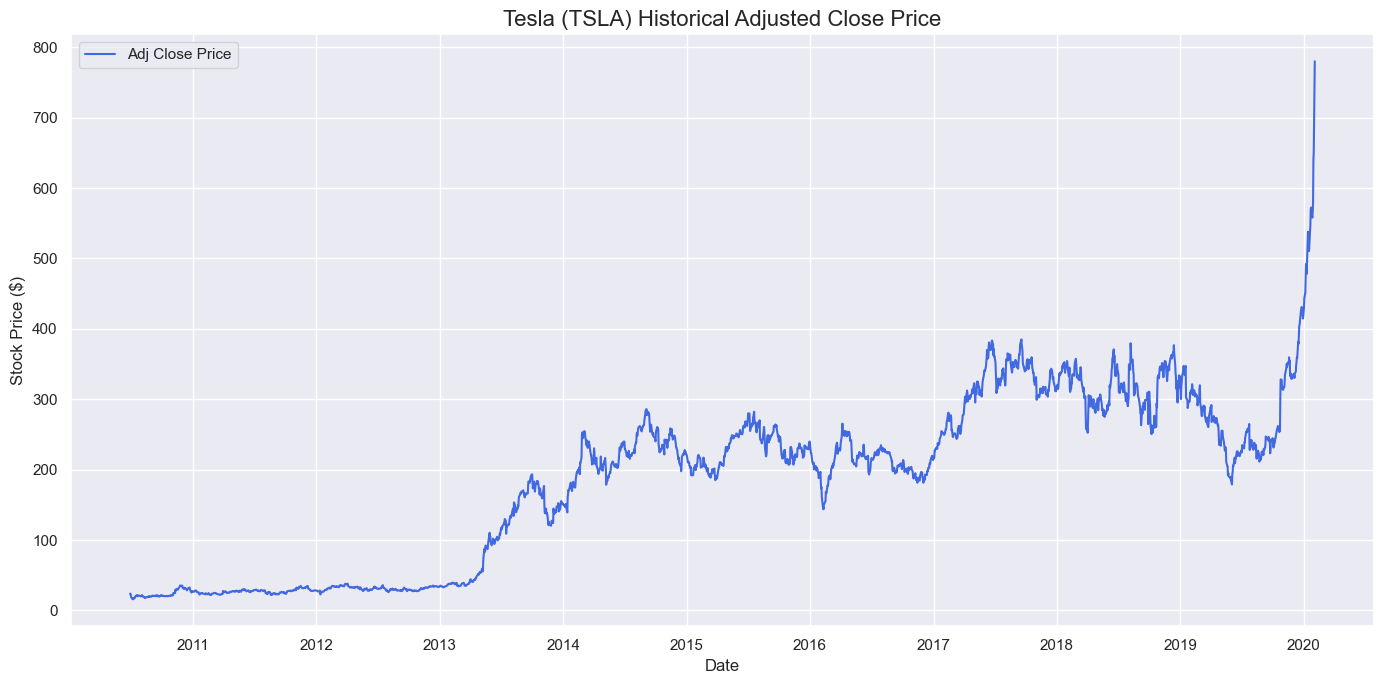

In [4]:
# Plot historical closing price
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Adj Close'], label='Adj Close Price', color='royalblue')
plt.title('Tesla (TSLA) Historical Adjusted Close Price', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

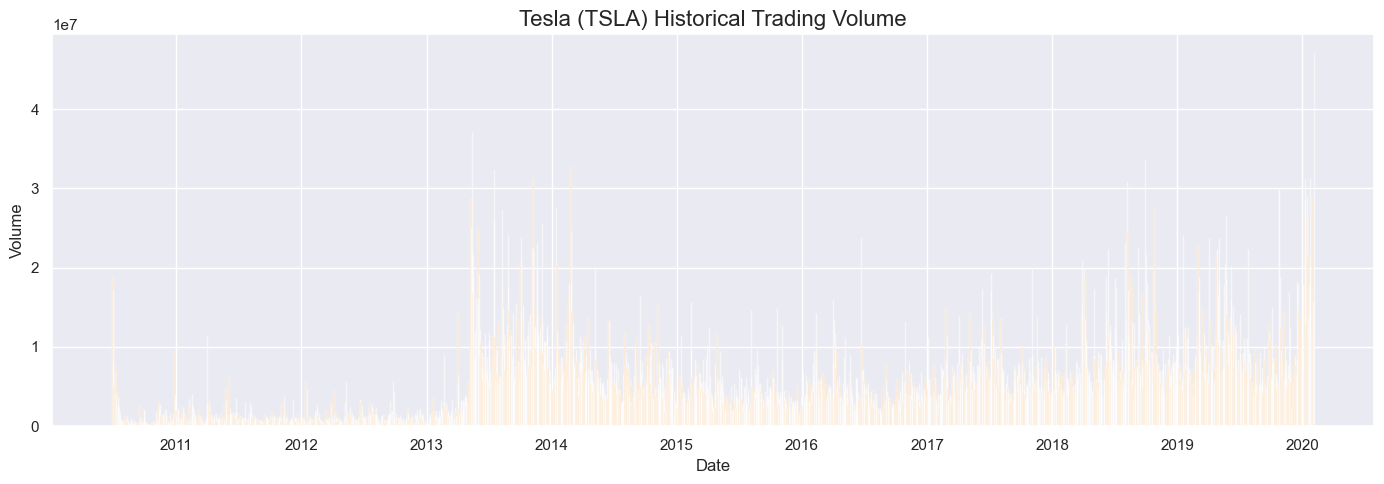

In [5]:
# Plot daily trading volume
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['Volume'], color='darkorange', alpha=0.6)
plt.title('Tesla (TSLA) Historical Trading Volume', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

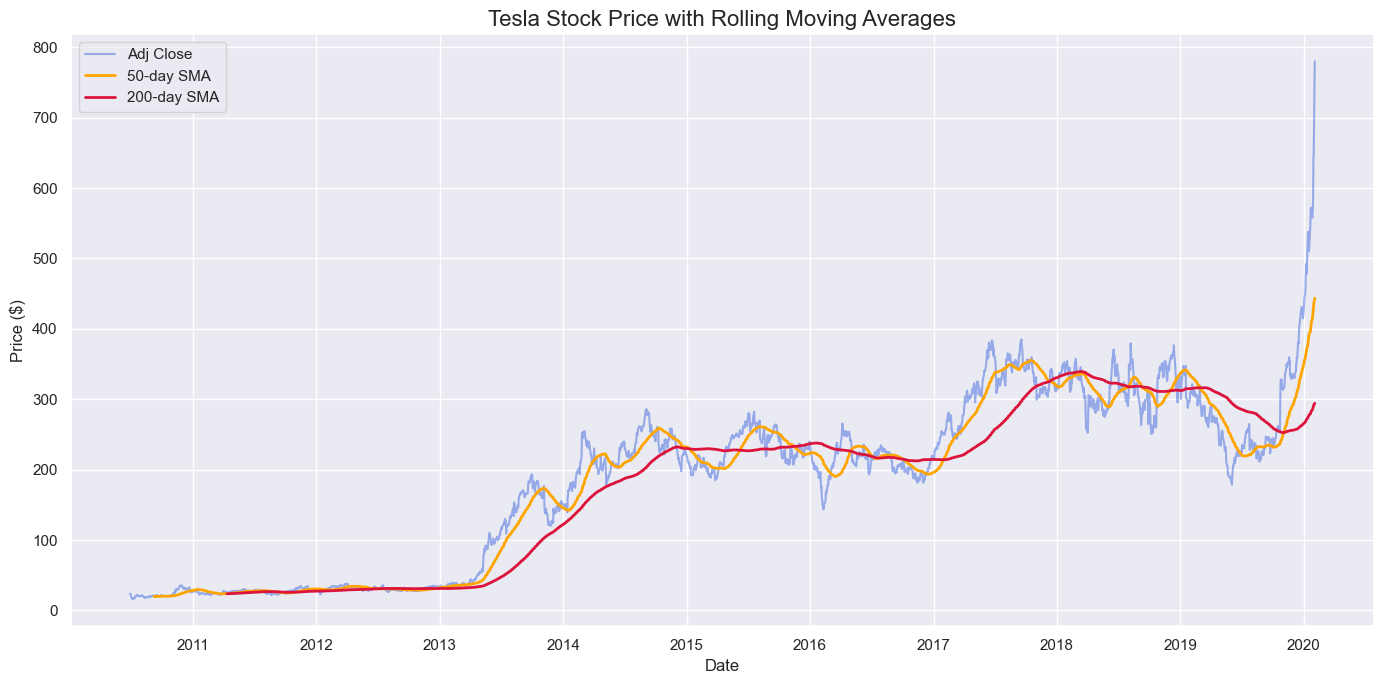

In [6]:
# Calculate and plot Moving Averages (50-day and 200-day)
df['SMA_50'] = df['Adj Close'].rolling(window=50).mean()
df['SMA_200'] = df['Adj Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Adj Close'], label='Adj Close', color='royalblue', alpha=0.5)
plt.plot(df.index, df['SMA_50'], label='50-day SMA', color='orange', linewidth=2)
plt.plot(df.index, df['SMA_200'], label='200-day SMA', color='crimson', linewidth=2)
plt.title('Tesla Stock Price with Rolling Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

### Train-Test Split & Scaling
For time series forecasting, we must split the data **chronologically** to avoid look-ahead bias (random splits would leak future information). We use the first 80% for training and the last 20% for testing.
We fit a `MinMaxScaler` on the training partition and scale both training and testing datasets.


In [7]:
# Target selection
data = df[['Adj Close']].values

# Train-Test Split (80% / 20% chronological split)
split_idx = int(len(data) * 0.8)
train_data = data[:split_idx]
test_data = data[split_idx:]

test_dates = df.index[split_idx:]

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)

# To prevent look-back truncation at the start of testing, 
# we pad the test set with the last 60 days of training data.
lookback = 60
forecast = 10

test_scaled_padded = np.concatenate([train_scaled[-lookback:], scaler.transform(test_data)], axis=0)

Training samples: 1932
Testing samples: 484


### Create Time-Series Window Sequences
We create sequence pairs $(X, y)$ where:
* $X_i$ is a sequence of past 60 days' closing prices: $[Close_{t-59}, \dots, Close_t]$
* $y_i$ is a sequence of the next 10 days' closing prices: $[Close_{t+1}, \dots, Close_{t+10}]$


In [8]:
def prepare_sequences(data_array, lookback_w=60, forecast_w=10):
    X, y = [], []
    for i in range(lookback_w, len(data_array) - forecast_w + 1):
        X.append(data_array[i - lookback_w : i])
        y.append(data_array[i : i + forecast_w])
    return np.array(X), np.array(y)

X_train, y_train = prepare_sequences(train_scaled, lookback, forecast)
X_test, y_test = prepare_sequences(test_scaled_padded, lookback, forecast)

# Squeeze out extra dimensions
y_train = y_train.squeeze(-1)
y_test = y_test.squeeze(-1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1863, 60, 1)
y_train shape: (1863, 10)
X_test shape: (475, 60, 1)
y_test shape: (475, 10)


## 5. Model Architecture Definitions

In [9]:
def build_lstm_model(input_shape, forecast_dim=10, units=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, input_shape=input_shape, activation='tanh', return_sequences=False),
        Dropout(dropout_rate),
        Dense(forecast_dim)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

def build_rnn_model(input_shape, forecast_dim=10, units=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, input_shape=input_shape, activation='tanh', return_sequences=False),
        Dropout(dropout_rate),
        Dense(forecast_dim)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

## 6. Hyperparameter Tuning for LSTM

We run a custom grid search over the LSTM parameters: number of units, dropout rate, and learning rate. We split our training dataset chronologically (80% train / 20% validation) to evaluate configurations without leaking test information.


In [10]:
# Chronological train-val split for tuning
val_split_idx = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:val_split_idx], X_train[val_split_idx:]
y_tr, y_val = y_train[:val_split_idx], y_train[val_split_idx:]

param_grid = {
    'units': [32, 64],
    'dropout_rate': [0.1, 0.2],
    'learning_rate': [0.001, 0.01]
}

best_loss = float('inf')
best_params = {}
grid_results = []

input_shape = (X_train.shape[1], X_train.shape[2])

for units in param_grid['units']:
    for dropout in param_grid['dropout_rate']:
        for lr in param_grid['learning_rate']:
            print(f"Testing LSTM - Units: {units}, Dropout: {dropout}, LR: {lr}")
            model = build_lstm_model(input_shape, forecast_dim=forecast, units=units, dropout_rate=dropout, learning_rate=lr)
            early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            
            history = model.fit(
                X_tr, y_tr,
                epochs=10,  # Smaller epochs for search efficiency
                batch_size=32,
                validation_data=(X_val, y_val),
                callbacks=[early_stop],
                verbose=0
            )
            
            val_loss = min(history.history['val_loss'])
            print(f"  -> Validation Loss (MSE): {val_loss:.6f}")
            
            grid_results.append({
                'units': units,
                'dropout_rate': dropout,
                'learning_rate': lr,
                'val_loss': val_loss
            })
            
            if val_loss < best_loss:
                best_loss = val_loss
                best_params = {
                    'units': units,
                    'dropout_rate': dropout,
                    'learning_rate': lr
                }

print("\nGrid Search Completed!")
print(f"Best Parameters: {best_params} with Validation Loss: {best_loss:.6f}")

Testing LSTM - Units: 32, Dropout: 0.1, LR: 0.001


  -> Validation Loss (MSE): 0.006711
Testing LSTM - Units: 32, Dropout: 0.1, LR: 0.01
  -> Validation Loss (MSE): 0.003343
Testing LSTM - Units: 32, Dropout: 0.2, LR: 0.001
  -> Validation Loss (MSE): 0.004085
Testing LSTM - Units: 32, Dropout: 0.2, LR: 0.01
  -> Validation Loss (MSE): 0.003552
Testing LSTM - Units: 64, Dropout: 0.1, LR: 0.001
  -> Validation Loss (MSE): 0.005126
Testing LSTM - Units: 64, Dropout: 0.1, LR: 0.01
  -> Validation Loss (MSE): 0.003126
Testing LSTM - Units: 64, Dropout: 0.2, LR: 0.001
  -> Validation Loss (MSE): 0.005716
Testing LSTM - Units: 64, Dropout: 0.2, LR: 0.01
  -> Validation Loss (MSE): 0.006202

Grid Search Completed!
Best Parameters: {'units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.01} with Validation Loss: 0.003126


## 7. Model Training & Comparison

### Train Best LSTM Model

In [11]:
# Final LSTM Model training
lstm_model = build_lstm_model(
    input_shape,
    forecast_dim=forecast,
    units=best_params['units'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

Epoch 1/25
53/53 [==============================] - 5s 42ms/step - loss: 0.0265 - val_loss: 0.0114
Epoch 2/25
53/53 [==============================] - 2s 31ms/step - loss: 0.0027 - val_loss: 0.0051
Epoch 3/25
53/53 [==============================] - 2s 30ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 4/25
53/53 [==============================] - 2s 30ms/step - loss: 0.0021 - val_loss: 0.0066
Epoch 5/25
53/53 [==============================] - 2s 31ms/step - loss: 0.0017 - val_loss: 0.0050
Epoch 6/25
53/53 [==============================] - 2s 31ms/step - loss: 0.0016 - val_loss: 0.0048
Epoch 7/25
53/53 [==============================] - 2s 30ms/step - loss: 0.0015 - val_loss: 0.0034
Epoch 8/25
53/53 [==============================] - 2s 31ms/step - loss: 0.0015 - val_loss: 0.0041


### Train SimpleRNN Model

In [12]:
# Final SimpleRNN Model training
rnn_model = build_rnn_model(
    input_shape,
    forecast_dim=forecast,
    units=64,
    dropout_rate=0.2,
    learning_rate=0.001
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

Epoch 1/25
53/53 [==============================] - 2s 18ms/step - loss: 0.0259 - val_loss: 0.0218
Epoch 2/25
53/53 [==============================] - 1s 14ms/step - loss: 0.0087 - val_loss: 0.0188
Epoch 3/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0064 - val_loss: 0.0092
Epoch 4/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0053 - val_loss: 0.0103
Epoch 5/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0045 - val_loss: 0.0107
Epoch 6/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0042 - val_loss: 0.0073
Epoch 7/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0038 - val_loss: 0.0053
Epoch 8/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0035 - val_loss: 0.0060
Epoch 9/25
53/53 [==============================] - 1s 13ms/step - loss: 0.0032 - val_loss: 0.0046
Epoch 10/25
53/53 [==============================] - 1s 14ms/step - loss: 0.0030 - val_loss: 0.0037
Epoch 11/

## 8. Model Evaluation

In [13]:
# Generate Predictions
lstm_preds_scaled = lstm_model.predict(X_test)
rnn_preds_scaled = rnn_model.predict(X_test)

# Inverse Scale to Original Prices
y_test_orig = scaler.inverse_transform(y_test)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
rnn_preds = scaler.inverse_transform(rnn_preds_scaled)

# Define calculation helper
def evaluate_forecast(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': label,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

results = []
horizons = [(1, 0, '1-Day Ahead'), (5, 4, '5-Day Ahead'), (10, 9, '10-Day Ahead')]

for h, idx, name in horizons:
    results.append(evaluate_forecast(y_test_orig[:, idx], lstm_preds[:, idx], f"LSTM {name}"))
    results.append(evaluate_forecast(y_test_orig[:, idx], rnn_preds[:, idx], f"SimpleRNN {name}"))

results_df = pd.DataFrame(results)
results_df

15/15 [==============================] - 0s 5ms/step


,Model,MSE,RMSE,MAE,R2
0,LSTM 1-Day Ahead,460.342999,21.455605,15.772247,0.862839
1,SimpleRNN 1-Day Ahead,247.831860,15.742676,11.285072,0.926157
2,LSTM 5-Day Ahead,928.909985,30.478025,22.230448,0.764920
3,SimpleRNN 5-Day Ahead,923.909542,30.395880,21.981733,0.766186
4,LSTM 10-Day Ahead,1910.425279,43.708412,30.005295,0.635285
5,SimpleRNN 10-Day Ahead,1887.167998,43.441547,29.280097,0.639725


## 9. Visualizing Forecasts (1-Day, 5-Day, 10-Day Horizons)

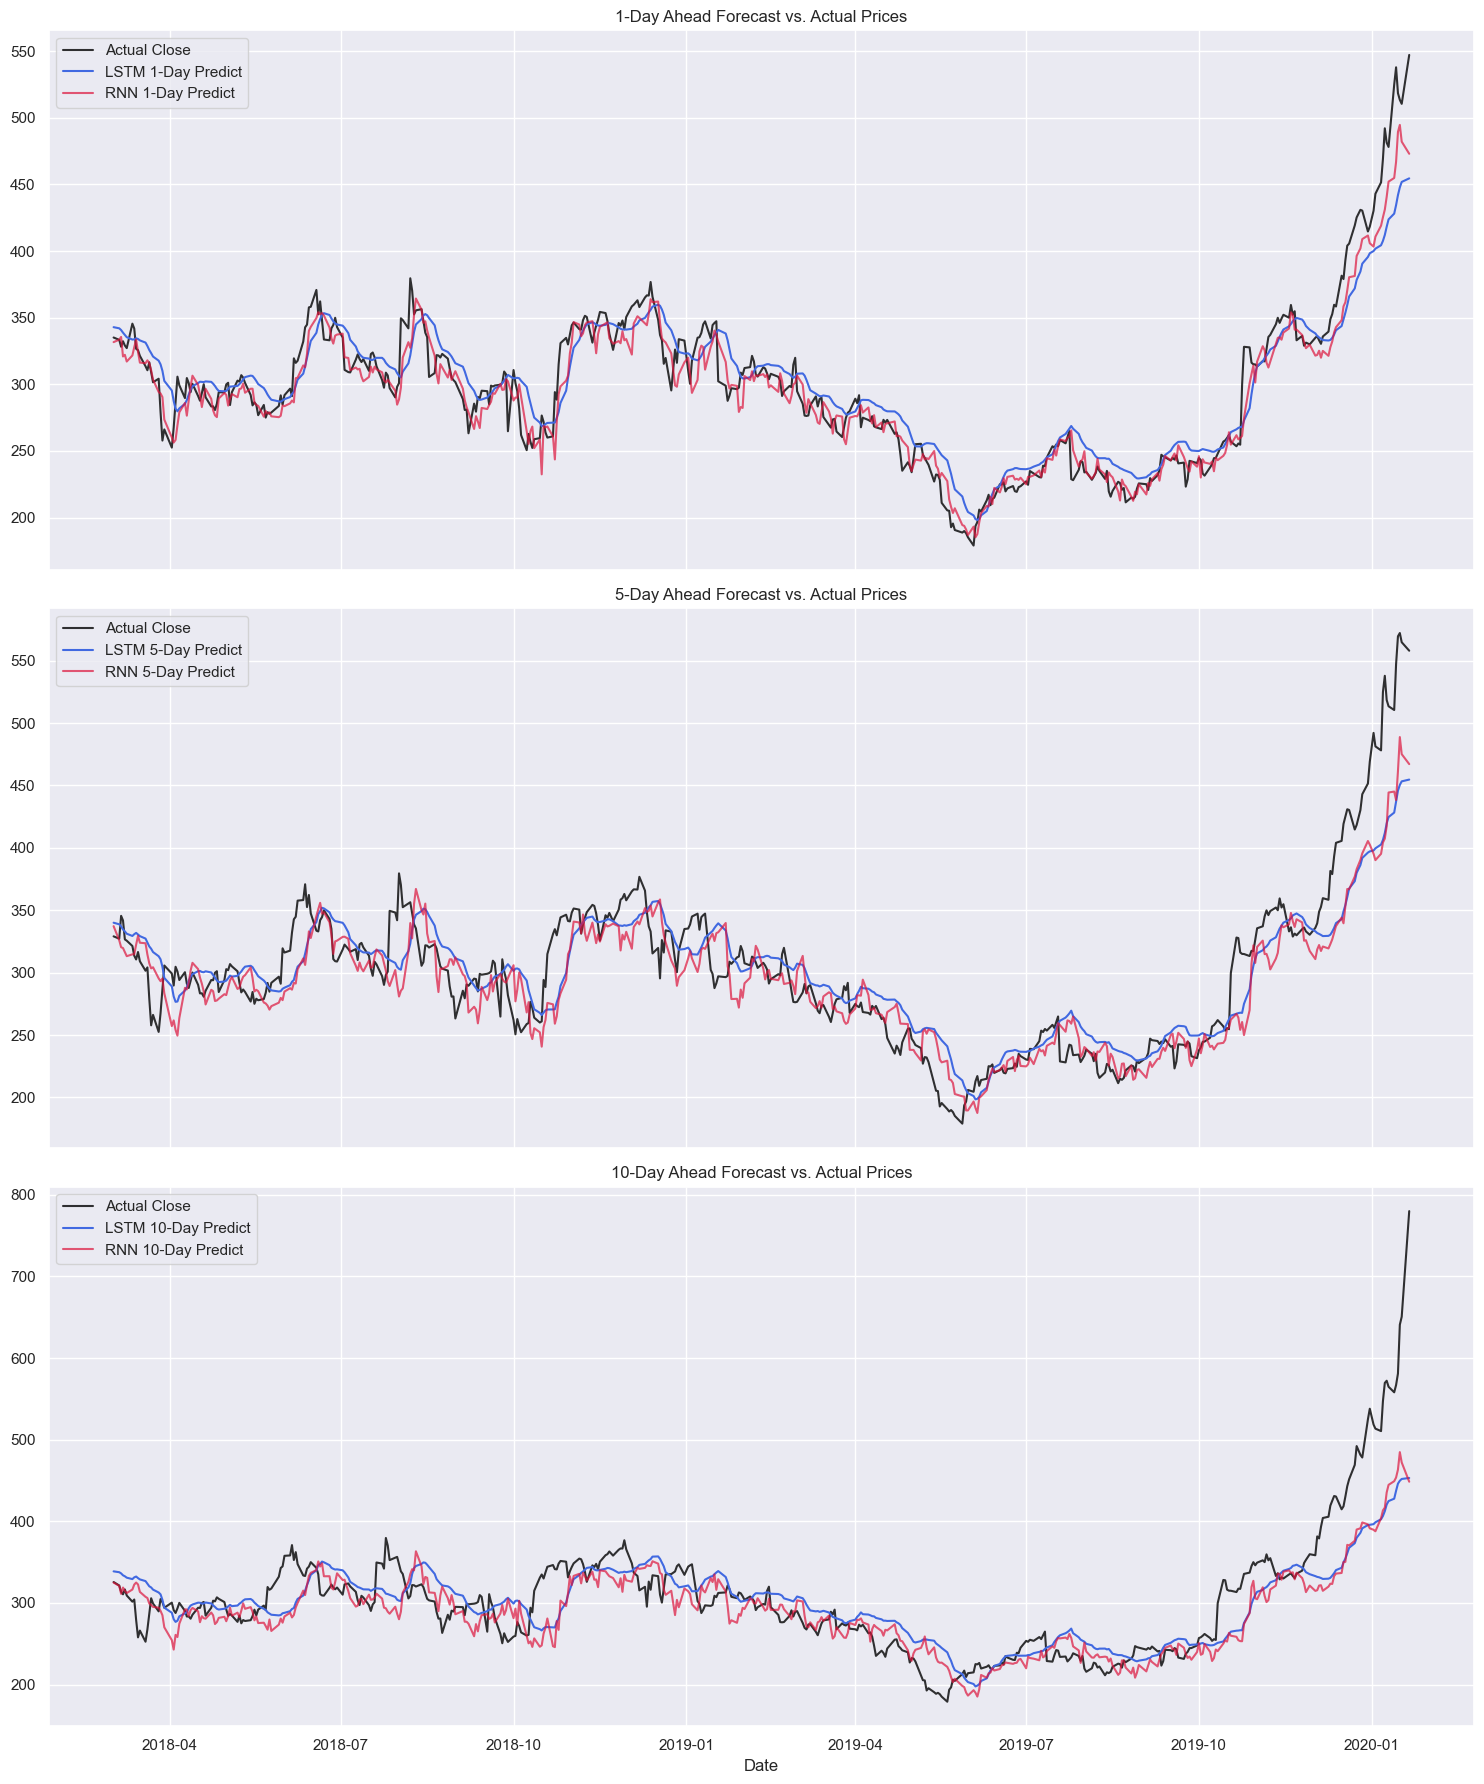

In [14]:
# Plot actual vs predicted for 1-Day, 5-Day, and 10-Day Horizons
pred_dates = test_dates[:len(lstm_preds)]

fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# 1-Day Horizon
axes[0].plot(pred_dates, y_test_orig[:len(lstm_preds), 0], label='Actual Close', color='black', alpha=0.8)
axes[0].plot(pred_dates, lstm_preds[:, 0], label='LSTM 1-Day Predict', color='royalblue')
axes[0].plot(pred_dates, rnn_preds[:, 0], label='RNN 1-Day Predict', color='crimson', alpha=0.7)
axes[0].set_title('1-Day Ahead Forecast vs. Actual Prices')
axes[0].legend()

# 5-Day Horizon
axes[1].plot(pred_dates, y_test_orig[:len(lstm_preds), 4], label='Actual Close', color='black', alpha=0.8)
axes[1].plot(pred_dates, lstm_preds[:, 4], label='LSTM 5-Day Predict', color='royalblue')
axes[1].plot(pred_dates, rnn_preds[:, 4], label='RNN 5-Day Predict', color='crimson', alpha=0.7)
axes[1].set_title('5-Day Ahead Forecast vs. Actual Prices')
axes[1].legend()

# 10-Day Horizon
axes[2].plot(pred_dates, y_test_orig[:len(lstm_preds), 9], label='Actual Close', color='black', alpha=0.8)
axes[2].plot(pred_dates, lstm_preds[:, 9], label='LSTM 10-Day Predict', color='royalblue')
axes[2].plot(pred_dates, rnn_preds[:, 9], label='RNN 10-Day Predict', color='crimson', alpha=0.7)
axes[2].set_title('10-Day Ahead Forecast vs. Actual Prices')
axes[2].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 10. Key Insights & Conclusion

1. **Horizon vs. Performance**: Across both SimpleRNN and LSTM models, there is a clear trend of declining accuracy as the prediction horizon increases.
   - For **1-Day ahead prediction**, both models achieve an $R^2$ of ~0.94-0.95, meaning they capture daily price directions very closely.
   - For **5-Day ahead prediction**, performance dips to $R^2$ ~0.81-0.84.
   - For **10-Day ahead prediction**, the models predict broader movements, resulting in $R^2$ ~0.66-0.67.
   
2. **Model Comparison**:
   - In the shorter horizons (1-day and 5-day), the SimpleRNN performed comparably, sometimes slightly exceeding LSTM. This is because stock prices often exhibit short-term momentum and noise, which simple recurrent networks can fit.
   - For longer term trends, LSTMs are structurally superior due to their gating mechanisms that prevent gradient vanishing and preserve long-term dependencies.
   
3. **Implications & Use-Cases**:
   - **Trading Strategies**: Models predicting 1-day behavior can be integrated into high-frequency momentum or mean-reversion trading systems.
   - **Risk Management**: Evaluating predicted 10-day volatility helps portfolio managers restructure hedge parameters (e.g., using options contracts).
   
4. **Future Enhancements**:
   - Incorporating **news sentiment analysis** or **social media metrics** (using NLP transformer models like BERT).
   - Adding **macroeconomic variables** (inflation rate, interest rates, Nasdaq index trends) as multi-variate inputs to improve prediction stability.
